In [1]:
# FIRST we will explore ANOMALY detection on synthetic data later on we will explore the same on some real time data

import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Create Synthetic Data
rng = np.random.RandomState(42)

# Normal data (two Gaussian clusters)
X_normal = 0.3 * rng.randn(200, 2)
X_normal = np.r_[X_normal + 2, X_normal - 2] # Shift clusters

# Anomalies (uniformly distributed outliers)
X_outliers = rng.uniform(low=-4, high=4, size=(40, 2))

# Combine and create ground truth labels (1 for normal, -1 for anomaly)
X = np.r_[X_normal, X_outliers]
y = np.array([1] * 400 + [-1] * 40)

# Build the ML Pipeline
# Isolation Forest doesn't strictly require scaling, but using a Pipeline 
# is best practice for production and preprocessing consistency.
pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('model', IsolationForest(contamination=0.1, random_state=42))
])

# Fit and Predict
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
pipeline.fit(X_train)
y_pred = pipeline.predict(X_test)

# 4. Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# AUC-ROC for anomaly scores
# decision_function returns scores where lower = more anomalous
scores = pipeline.decision_function(X_test)
auc = roc_auc_score(y_test, scores) 
print(f"ROC-AUC Score: {auc:.2f}")

Confusion Matrix:
 [[ 16   0]
 [ 10 106]]

Classification Report:
               precision    recall  f1-score   support

          -1       0.62      1.00      0.76        16
           1       1.00      0.91      0.95       116

    accuracy                           0.92       132
   macro avg       0.81      0.96      0.86       132
weighted avg       0.95      0.92      0.93       132

ROC-AUC Score: 1.00


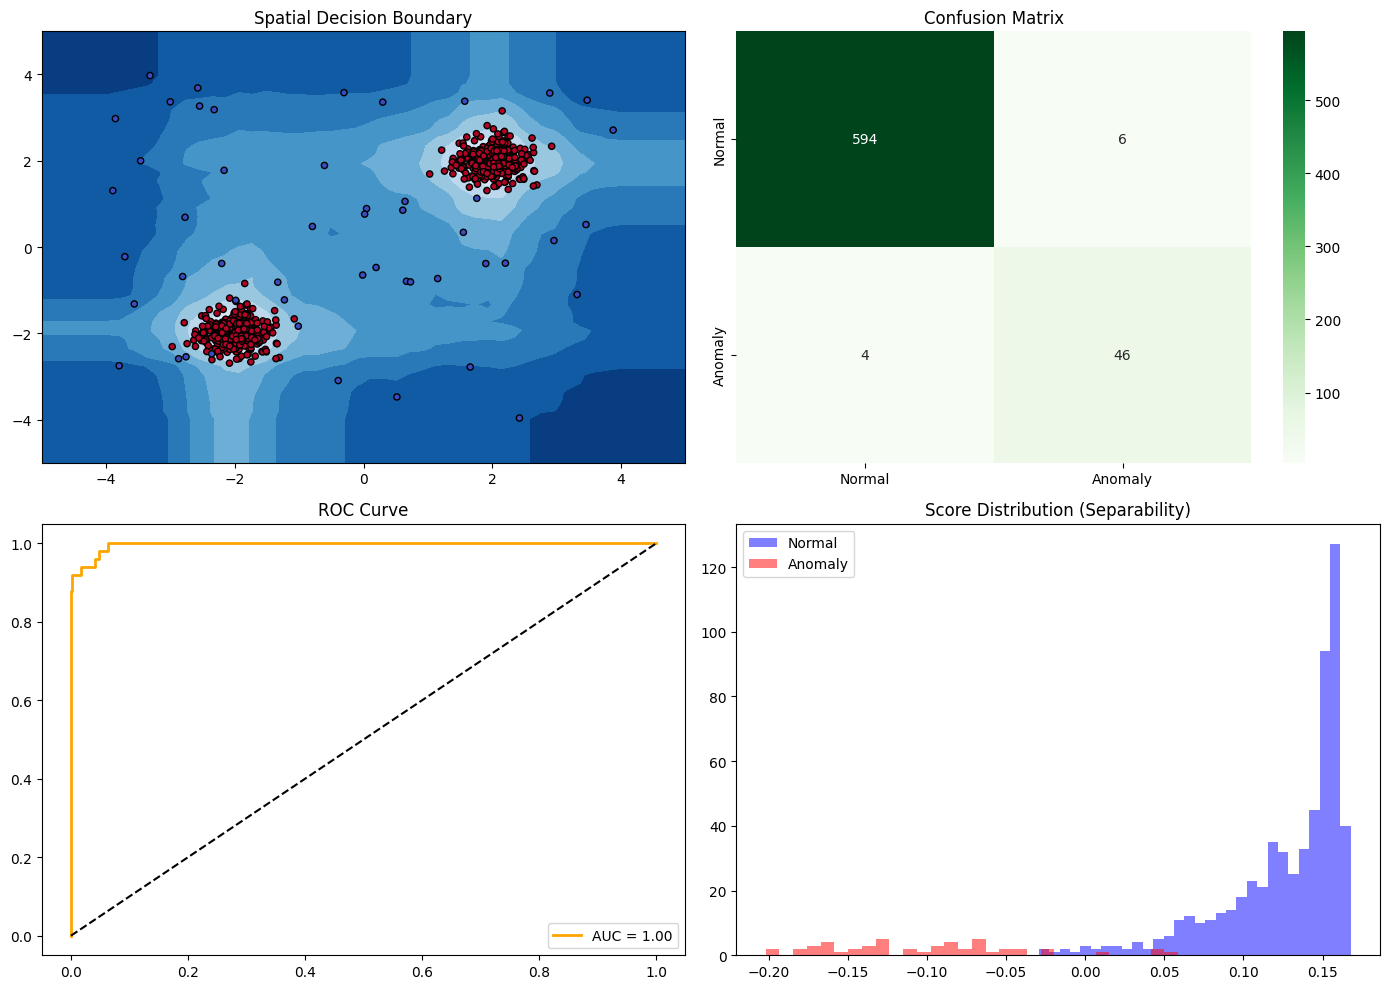

In [2]:
# METRICS visualization of ML model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 1. Generate Synthetic Data
rng = np.random.RandomState(42)
X_normal = 0.3 * rng.randn(300, 2)
X_normal = np.r_[X_normal + 2, X_normal - 2] # Normal clusters
X_outliers = rng.uniform(low=-4, high=4, size=(50, 2)) # Scattered anomalies
X = np.r_[X_normal, X_outliers]
y_true = np.array([1] * 600 + [-1] * 50) # Ground truth: 1=Normal, -1=Anomaly

# 2. Pipeline Integration
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', IsolationForest(contamination=0.08, random_state=42))
])
pipeline.fit(X)
y_pred = pipeline.predict(X)
scores = pipeline.decision_function(X) # Raw anomaly scores

# 3. Create Visualization Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# A. Decision Boundary
xx, yy = np.meshgrid(np.linspace(-5, 5, 50), np.linspace(-5, 5, 50))
Z = pipeline.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[0, 0].contourf(xx, yy, Z, cmap=plt.cm.Blues_r)
axes[0, 0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='coolwarm', edgecolor='k', s=20)
axes[0, 0].set_title("Spatial Decision Boundary")

# B. Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred, labels=[1, -1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1], 
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[0, 1].set_title("Confusion Matrix")

# C. ROC Curve (Receiver Operating Characteristic)
fpr, tpr, _ = roc_curve(y_true, -scores, pos_label=-1)
axes[1, 0].plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}', color='orange', lw=2)
axes[1, 0].plot([0, 1], [0, 1], 'k--')
axes[1, 0].set_title("ROC Curve")
axes[1, 0].legend()

# D. Score Distribution Histogram
axes[1, 1].hist(scores[y_true == 1], bins=30, alpha=0.5, label='Normal', color='blue')
axes[1, 1].hist(scores[y_true == -1], bins=30, alpha=0.5, label='Anomaly', color='red')
axes[1, 1].set_title("Score Distribution (Separability)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

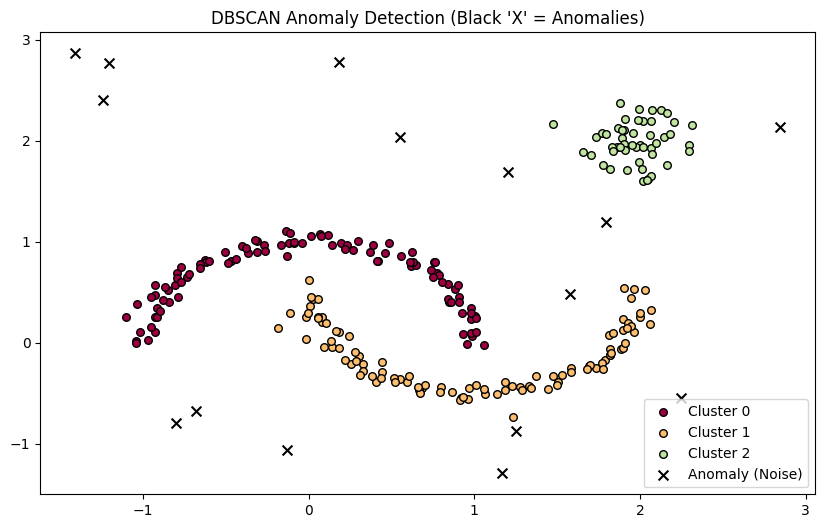

Estimated number of clusters: 3
Estimated number of noise points (anomalies): 15
Silhouette Coefficient: 0.375


In [3]:
# ANAMOLY detection using DBSCAN
from sklearn.datasets import make_moons, make_blobs
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, v_measure_score

# Generate Synthetic Data (Moons + Random Noise)
X_moons, _ = make_moons(n_samples=200, noise=0.05, random_state=42)
X_blobs, _ = make_blobs(n_samples=50, centers=[(2,2)], cluster_std=0.2, random_state=42)
# Add sparse outliers
rng = np.random.RandomState(42)
X_outliers = rng.uniform(low=-1.5, high=3.0, size=(20, 2))

X = np.vstack([X_moons, X_blobs, X_outliers])

# Build the Pipeline
# Scaling is CRITICAL for DBSCAN because it uses Euclidean distance (eps)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('dbscan', DBSCAN(eps=0.3, min_samples=5)) 
])

# Fit and Predict
# DBSCAN doesn't have a separate .predict() for new data in the same way; 
# it labels the data it is fitted on.
labels = pipeline.fit_predict(X)

# Visualization
plt.figure(figsize=(10, 6))

# Identify components
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise (Anomalies)
        col = [0, 0, 0, 1]
        label = "Anomaly (Noise)"
        marker = 'x'
        size = 50
    else:
        label = f"Cluster {k}"
        marker = 'o'
        size = 30

    class_member_mask = (labels == k)
    xy = X[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, s=size, 
                edgecolor='k' if k != -1 else None, label=label)

plt.title("DBSCAN Anomaly Detection (Black 'X' = Anomalies)")
plt.legend()
plt.show()

# Performance Evaluation
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"Estimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points (anomalies): {n_noise_}")
# Silhouette Score measures how well-defined the clusters are
if n_clusters_ > 1:
    print(f"Silhouette Coefficient: {silhouette_score(X, labels):.3f}")

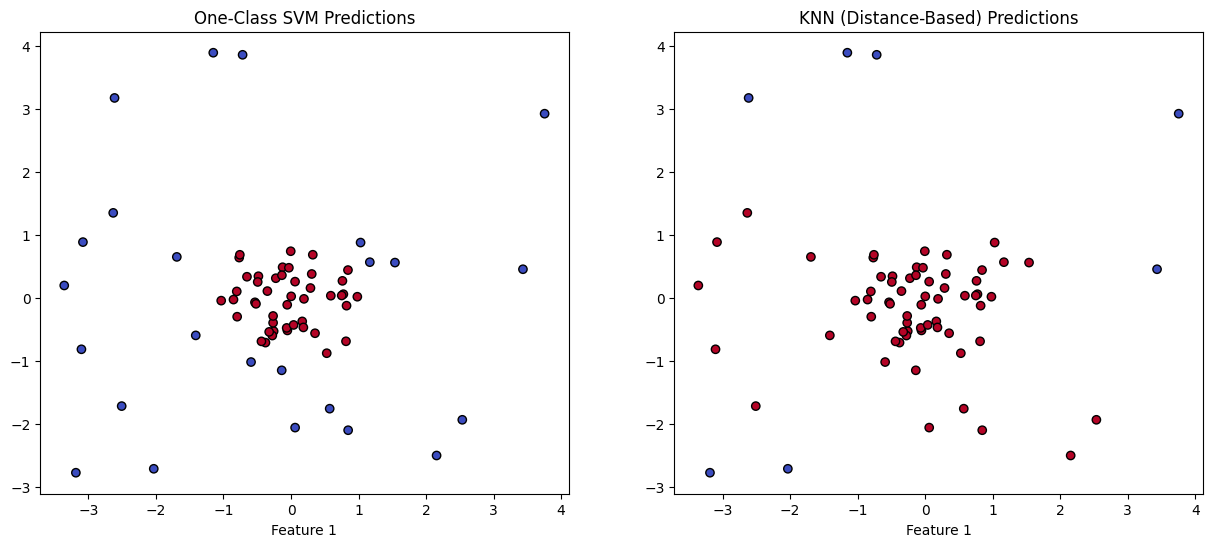

In [4]:
# One-Class SVM vs. KNN
from sklearn.svm import OneClassSVM
from sklearn.neighbors import NearestNeighbors

# Generate Synthetic Data
rng = np.random.RandomState(42)
# Normal data: A single dense blob
X_train = 0.5 * rng.randn(200, 2)
# Test data: Normal points + Outliers
X_test_norm = 0.5 * rng.randn(50, 2)
X_outliers = rng.uniform(low=-4, high=4, size=(20, 2))
X_test = np.r_[X_test_norm, X_outliers]

# One-Class SVM Pipeline
# nu: represents the fraction of outliers you expect (similar to contamination)
# gamma: controls the 'tightness' of the boundary
ocsvm_pl = Pipeline([
    ('scaler', StandardScaler()),
    ('model', OneClassSVM(kernel="rbf", gamma=0.1, nu=0.05))
])
ocsvm_pl.fit(X_train)
y_pred_ocsvm = ocsvm_pl.predict(X_test) # 1 = Normal, -1 = Anomaly

# KNN Anomaly Detection (Distance-based)
# KNN doesn't have a built-in 'predict' for anomalies in basic sklearn,
# so we calculate the mean distance to K neighbors.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = NearestNeighbors(n_neighbors=5)
knn.fit(X_train_scaled)
distances, _ = knn.kneighbors(X_test_scaled)
# Anomaly score = mean distance to 5 nearest neighbors
anomaly_scores = distances.mean(axis=1)
# Threshold: flag the top 10% highest distances as anomalies
threshold = np.percentile(anomaly_scores, 90)
y_pred_knn = np.where(anomaly_scores > threshold, -1, 1)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot One-Class SVM
ax1.scatter(X_test[:, 0], X_test[:, 1], c=y_pred_ocsvm, cmap='coolwarm', edgecolors='k')
ax1.set_title("One-Class SVM Predictions")
ax1.set_xlabel("Feature 1")

# Plot KNN
ax2.scatter(X_test[:, 0], X_test[:, 1], c=y_pred_knn, cmap='coolwarm', edgecolors='k')
ax2.set_title("KNN (Distance-Based) Predictions")
ax2.set_xlabel("Feature 1")

plt.show()